# microAutoware latency evaluation
## Latency data processing
---

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

# import scienceplots

# plt.style.use(['science','ieee'])

/home/toffanetto/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/toffanetto/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/toffanetto/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Latencies in Autoware mode fo steering

### Importing data

In [2]:

csv_file = '05122024_131121_latencies'

csv_df = pd.read_csv('../data/'+csv_file+'.csv')
# print(csv_df)
column_names = csv_df.columns
# print(column_names)

### Getting vectors of latencies and periods

In [3]:
steering_latency_raw = csv_df['Latency steering'].to_list()
steering_period_raw = csv_df['Period steering'].to_list()
velocity_latency_raw = csv_df['Latency velocity'].to_list()
velocity_period_raw = csv_df['Period velocity'].to_list()

steering_latency = np.array([x for x in steering_latency_raw  if x >= 0])
steering_period = np.array([x for x in steering_period_raw  if x >= 0])
velocity_latency = np.array([x for x in velocity_latency_raw  if x >= 0])
velocity_period = np.array([x for x in velocity_period_raw  if x >= 0])

steering_latency_mean = steering_latency.mean()
steering_latency_std = steering_latency.std()

steering_period_mean = steering_period.mean()
steering_period_std = steering_period.std()

steering_count_not_real_time = 0

for l, p in zip(steering_latency, steering_period):
    if l > p:
        steering_count_not_real_time = steering_count_not_real_time + 1
        print(str(l)+" "+str(p))
        
steering_perc_not_real_time = steering_count_not_real_time/steering_latency.size

velocity_latency_mean = velocity_latency.mean()
velocity_latency_std = velocity_latency.std()

velocity_period_mean = velocity_period.mean()
velocity_period_std = velocity_period.std()

velocity_count_not_real_time = 0

for l, p in zip(velocity_latency, velocity_period):
    if l > p:
        velocity_count_not_real_time = velocity_count_not_real_time + 1
        
veloctiy_period_perc_not_real_time = velocity_count_not_real_time/velocity_latency.size


print("len: steering_latency "+str(len(steering_latency)))
print("steering_latency_mean: "+str(steering_latency_mean/1e6)+' ms')
print("steering_latency_std: "+str(steering_latency_std/1e6)+' ms')
print("steering_latency_max: "+str(steering_latency.max()/1e6)+' ms')
print("steering_period_mean: "+str(steering_period_mean/1e6)+' ms')
print("steering_period_std: "+str(steering_period_std/1e6)+' ms')
print("steering_period_max: "+str(steering_period.max()/1e6)+' ms')
print("steering_count_not_real_time: "+str(steering_count_not_real_time))
print("steering_perc_not_real_time: "+str(steering_perc_not_real_time))
# print("velocity_latency_mean: "+str(velocity_latency_mean))
# print("velocity_latency_std: "+str(velocity_latency_std))
# print("velocity_period_mean: "+str(velocity_period_mean))
# print("velocity_period_std: "+str(velocity_period_std))
# print("velocity_count_not_real_time: "+str(velocity_count_not_real_time))
# print("")



len: steering_latency 7847
steering_latency_mean: 32.461509081177525 ms
steering_latency_std: 7.665000526039375 ms
steering_latency_max: 52.740352 ms
steering_period_mean: 98.33669427641136 ms
steering_period_std: 52.842718180999505 ms
steering_period_max: 528.000874 ms
steering_count_not_real_time: 0
steering_perc_not_real_time: 0.0


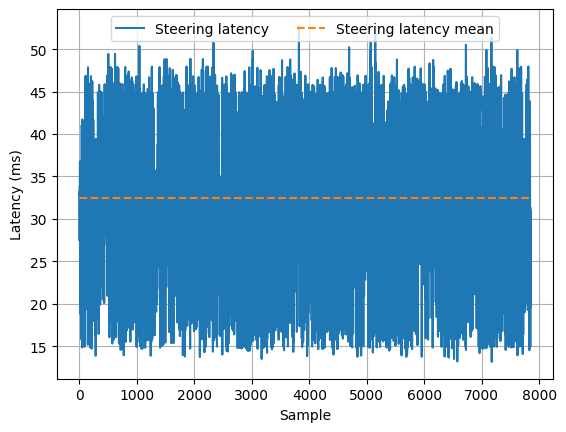

In [4]:
plt.figure()
# plt.plot(velocity_latency/1e6, label='Velocity latency')
# plt.plot(np.ones(velocity_latency.size)*velocity_latency_mean/1e6, '--', label='Velocity latency mean')
plt.plot(steering_latency/1e6, label='Steering latency')
plt.plot(np.ones(steering_latency.size)*steering_latency_mean/1e6, '--', label='Steering latency mean')
plt.legend(loc = 'upper center', ncol=2)
# plt.ylim([14, 55])
# plt.xlim([0, steering_latency.size])
plt.xlabel("Sample")
plt.ylabel("Latency (ms)")
plt.grid()

Text(0.5, 0, 'Time (ms)')

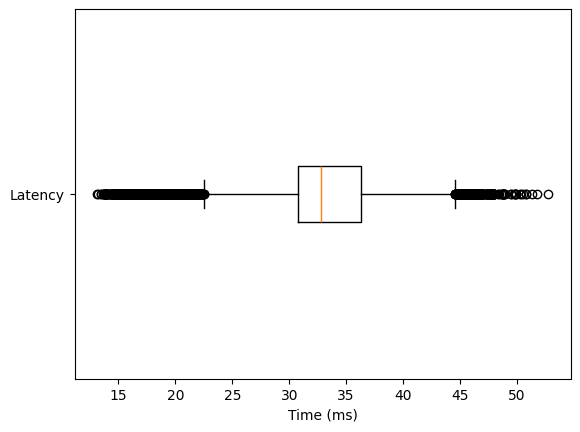

In [5]:
plt.figure()
plt.boxplot([steering_latency/1e6],vert=False)
plt.yticks([1],['Latency'])
plt.xlabel('Time (ms)')

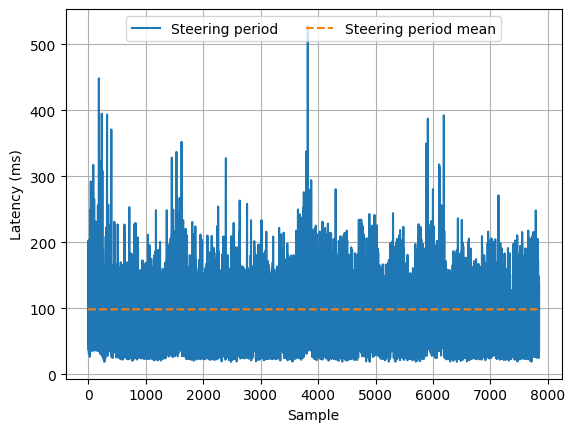

In [6]:
plt.figure()
plt.plot(steering_period/1e6, label='Steering period')
plt.plot(np.ones(steering_period.size)*steering_period_mean/1e6, '--', label='Steering period mean')
plt.legend(loc = 'upper center', ncol=2)
plt.xlabel("Sample")
plt.ylabel("Latency (ms)")
plt.grid()

Text(0.5, 0, 'Time (ms)')

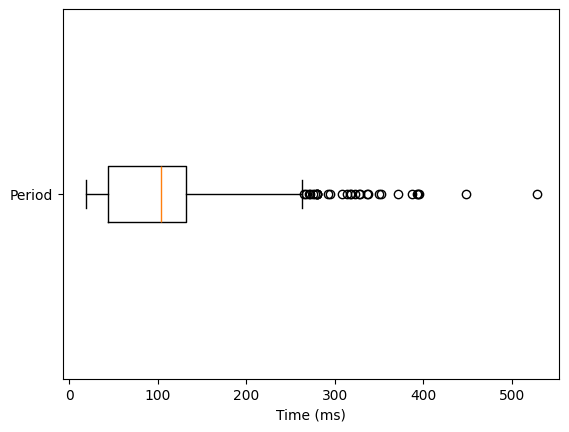

In [7]:
plt.figure()
plt.boxplot([steering_period/1e6],vert=False)
plt.yticks([1],['Period'])
plt.xlabel('Time (ms)')

---
## Latencies in Manual Mode - Steering and Velocity

In [8]:

csv_file = '03122024_112729_latencies_without_autoware_manual'

csv_df = pd.read_csv('../data/'+csv_file+'.csv')
# print(csv_df)
column_names = csv_df.columns
# print(column_names)

In [9]:
steering_latency_raw = csv_df['Latency steering'].to_list()
steering_period_raw = csv_df['Period steering'].to_list()
velocity_latency_raw = csv_df['Latency velocity'].to_list()
velocity_period_raw = csv_df['Period velocity'].to_list()

steering_latency = np.array([x for x in steering_latency_raw  if x >= 0])
steering_period = np.array([x for x in steering_period_raw  if x >= 0])
velocity_latency = np.array([x for x in velocity_latency_raw  if x >= 0])
velocity_period = np.array([x for x in velocity_period_raw  if x >= 0])

steering_latency_mean = steering_latency.mean()
steering_latency_std = steering_latency.std()

steering_period_mean = steering_period.mean()
steering_period_std = steering_period.std()

steering_count_not_real_time = 0

for l, p in zip(steering_latency, steering_period):
    if l > p:
        steering_count_not_real_time = steering_count_not_real_time + 1
        
steering_perc_not_real_time = steering_count_not_real_time/steering_latency.size

velocity_latency_mean = velocity_latency.mean()
velocity_latency_std = velocity_latency.std()

velocity_period_mean = velocity_period.mean()
velocity_period_std = velocity_period.std()

velocity_count_not_real_time = 0

for l, p in zip(velocity_latency, velocity_period):
    if l > p:
        velocity_count_not_real_time = velocity_count_not_real_time + 1
        
veloctiy_period_perc_not_real_time = velocity_count_not_real_time/velocity_latency.size



print("steering_latency_mean: "+str(steering_latency_mean/1e6)+' ms')
print("steering_latency_std: "+str(steering_latency_std/1e6)+' ms')
print("steering_period_mean: "+str(steering_period_mean/1e6)+' ms')
print("steering_period_std: "+str(steering_period_std/1e6)+' ms')
print("steering_perc_not_real_time: "+str(steering_perc_not_real_time))
print("")
print("velocity_latency_mean: "+str(velocity_latency_mean/1e6)+' ms')
print("velocity_latency_std: "+str(velocity_latency_std/1e6)+' ms')
print("velocity_period_mean: "+str(velocity_period_mean/1e6)+' ms')
print("velocity_period_std: "+str(velocity_period_std/1e6)+' ms')
print("velocity_count_not_real_time: "+str(velocity_count_not_real_time))
print("")

steering_latency_mean: 28.125882796747966 ms
steering_latency_std: 3.846408015476678 ms
steering_period_mean: 114.06998863414634 ms
steering_period_std: 48.82482880708325 ms
steering_perc_not_real_time: 0.0

velocity_latency_mean: 24.68447167479675 ms
velocity_latency_std: 3.7165620032564486 ms
velocity_period_mean: 114.06957024796748 ms
velocity_period_std: 48.73274718302004 ms
velocity_count_not_real_time: 0



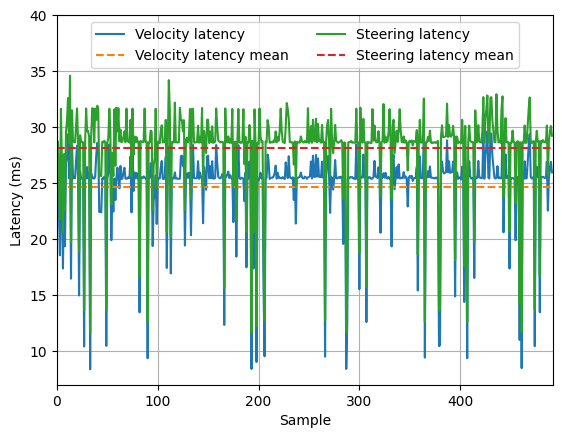

In [10]:
plt.figure()
plt.plot(velocity_latency/1e6, label='Velocity latency')
plt.plot(np.ones(velocity_latency.size)*velocity_latency_mean/1e6, '--', label='Velocity latency mean')
plt.plot(steering_latency/1e6, label='Steering latency')
plt.plot(np.ones(steering_latency.size)*steering_latency_mean/1e6, '--', label='Steering latency mean')
plt.legend(loc = 'upper center', ncol=2)
plt.ylim([7, 40])
plt.xlim([0, steering_latency.size])
plt.xlabel("Sample")
plt.ylabel("Latency (ms)")
plt.grid()